In [142]:
# Используем стандартные значения полос во всех функциях ниже
bands_freq = {"delta_min":1,"delta_max":3.5,
              "theta_min":4,"theta_max":6.5,
              "alpha_min":7,"alpha_max":13,
              "beta1_min":14,"beta1_max":20,
              "beta2_min":21,"beta2_max":30,
              "gamma_min":30,"gamma_max":48}

In [143]:
from scipy import linalg
import glob
import math
import scipy
from scipy import fftpack
from scipy.signal import butter, lfilter, hilbert
import scipy.interpolate
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import gc
import sys
import os
import os.path, time
import csv

import mne
import mnelab
from mnelab.io import read_raw
from mne import setup_volume_source_space, setup_source_space
from mne.viz import circular_layout
from mne import io
from mne_connectivity import spectral_connectivity_epochs
from mne_connectivity.viz import plot_connectivity_circle, plot_sensors_connectivity
from mne.viz.backends.renderer import _get_renderer

In [144]:
def matrix2line(_matrix):
    line2return = []
    len1 = _matrix.shape[0]
    len2 = _matrix.shape[1]
    for i in range(0,len1):
        for j in range(0,len2):
            if _matrix[i,j] != 0:
                line2return.append(_matrix[i,j])
    return line2return

In [145]:
# читаем файлы https://mne.tools/stable/generated/mne.io.read_raw_edf.html
edffile_state1 = "cleaned_data/1 open eyes_clean.edf"
edffile_state2 = "cleaned_data/2 closed eyes_clean.edf"

raw_mne1 = mne.io.read_raw_edf(edffile_state1, preload=True)
print(raw_mne1.n_times)
print(raw_mne1.ch_names)
print(raw_mne1.info)
print(raw_mne1.info['sfreq'])
print(raw_mne1.get_data().shape)

raw_mne2 = mne.io.read_raw_edf(edffile_state2, preload=True)
print(raw_mne2.n_times)
print(raw_mne2.ch_names)
print(raw_mne2.info)
print(raw_mne2.info['sfreq'])
print(raw_mne2.get_data().shape)

Extracting EDF parameters from cleaned_data/1 open eyes_clean.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 4999  =      0.000 ...    39.992 secs...
5000
['O1', 'T3', 'Fp1', 'Fp2', 'T4', 'O2']
<Info | 8 non-empty values
 bads: []
 ch_names: O1, T3, Fp1, Fp2, T4, O2
 chs: 6 EEG
 custom_ref_applied: False
 highpass: 2.0 Hz
 lowpass: 40.0 Hz
 meas_date: 2026-01-24 16:11:49 UTC
 nchan: 6
 projs: []
 sfreq: 125.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>
125.0
(6, 5000)
Extracting EDF parameters from cleaned_data/2 closed eyes_clean.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6249  =      0.000 ...    49.992 secs...
6250
['O1', 'T3', 'Fp1', 'Fp2', 'T4', 'O2']
<Info | 8 non-empty values
 bads: []
 ch_names: O1, T3, Fp1, Fp2, T4, O2
 chs: 6 EEG
 custom_ref_applied: False
 highpass: 2.0 Hz
 lowpass: 40.0 Hz
 meas_date: 2026-01-24 16:13:10 UTC
 nchan: 6
 projs: []
 sfreq: 125.0 Hz
 subje

In [146]:
# Сначала анализируем первую запись, потом вторую
# Везде по коду используется raw_mne_main и edffile_state_main
# Вам для задания сравния двух записей надо будет потом поменять код и блоки
raw_mne_main = raw_mne1
edffile_state_main = edffile_state1

In [147]:
# Константы и объекты для работы с функциональной связностью
# Количество каналов
nchan = 6

# Устанавливаем частоты для анализа
# Набор частот по конкретной полосе
#fmin = bands_freq["beta1_min"]
#fmax = bands_freq["beta1_max"]
# Полный набор частот
fmin = bands_freq["delta_min"]
fmax = bands_freq["gamma_max"]
print('fmin: '+str(fmin))
print('fmax: '+str(fmax))

# Работаем по записи скользящим окном
window_length = 30 # ширина скользящего окна в секундах
epoch_length = 5 # длина эпохи в секундах, на сколько сдвигаем окно

# Количество окон для анализа
windows_count_to_analyse = math.floor(int(raw_mne_main.times[-1]-window_length)/epoch_length)
print('windows_count_to_analyse: '+str(windows_count_to_analyse))

# Создаем общий массив для вывода результатов анализа всех windows
array2csv = np.empty((windows_count_to_analyse),dtype=object)

# Частота дискретизации
sample_rate = raw_mne_main.info['sfreq']
print('sample_rate: '+str(sample_rate))

# Indices of good channels https://mne.tools/stable/generated/mne.pick_types.html
picks = mne.pick_types(raw_mne_main.info, eeg=True)
print('Indices of good channels: '+str(picks))

fmin: 1
fmax: 48
windows_count_to_analyse: 1
sample_rate: 125.0
Indices of good channels: [0 1 2 3 4 5]


In [148]:
# Считаем основной массив, в который вносим значения функциональной связности
# Нужно поработать с 'coh' методом, потом с 'plv' методом

# Используемая функция https://mne.tools/stable/generated/mne.connectivity.spectral_connectivity.html

windows_ids_to_analyse = []
for window in range(0,windows_count_to_analyse):
    n_epochs = math.floor(int(window_length/epoch_length))
    # создаем временный файл событий для анализа связности по эпохам, т.к. у нас "простой" аппарат для записи и нет событий
    f= open("temp_events.txt","w")
    for i in range(0,n_epochs):
        f.write(str(int((i*epoch_length+window*epoch_length)*raw_mne_main.info['sfreq'])) + " 0 1\n")
    f.close()
    # читаем события и создаем эпохи 
    events = mne.read_events("temp_events.txt")
    print(events)
    # работаем со скользящим окном
    epochs = mne.Epochs(raw_mne_main, events, tmin=0, tmax=epoch_length, picks=picks,baseline=None)
    os.remove("temp_events.txt")
    # method='coh'
    con = spectral_connectivity_epochs(epochs, method='coh', mode='fourier', sfreq=sample_rate, fmin=fmin, fmax=fmax, faverage=True, n_jobs=1)
    # method='plv'
    #con = spectral_connectivity_epochs(epochs, method='plv', mode='fourier', sfreq=sample_rate, fmin=fmin, fmax=fmax, faverage=True, n_jobs=1)
    array2csv[window] = con.get_data(output='dense')[:, :, 0]
    windows_ids_to_analyse.append(window)
    del epochs, con

[[   0    0    1]
 [ 625    0    1]
 [1250    0    1]
 [1875    0    1]
 [2500    0    1]
 [3125    0    1]]
Not setting metadata
6 matching events found
No baseline correction applied
0 projection items activated
Adding metadata with 3 columns
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 15 connections
    using t=0.000s..5.000s for estimation (626 points)
    frequencies: 1.2Hz..47.9Hz (235 points)
    connectivity scores will be averaged for each band
    using FFT with a Hanning window to estimate spectra
    the following metrics will be computed: Coherence
    computing cross-spectral density for epoch 1
    computing cross-spectral density for epoch 2
    computing cross-spectral density for epoch 3
    computing cross-spectral density for epoch 4
    computing cross-spectral density for epoch 5
    computing cross-spectral density for epoch 6
    assembling connectivity matrix
[Connectivity computation done]


/var/folders/nn/k7hz9z1j2l7_xhltzy4b04q40000gn/T/ipykernel_8590/597068483.py:15: RuntimeWarning: This filename (temp_events.txt) does not conform to MNE naming conventions. All events files should end with .eve, -eve.fif, -eve.fif.gz, -eve.lst, -eve.txt, _eve.fif, _eve.fif.gz, _eve.lst, _eve.txt or -annot.fif
  events = mne.read_events("temp_events.txt")


In [149]:
# Посмотрим, что же получилось
print(array2csv)

[array([[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        ],
        [0.4494447 , 0.        , 0.        , 0.        , 0.        ,
         0.        ],
        [0.38671479, 0.46725953, 0.        , 0.        , 0.        ,
         0.        ],
        [0.38555964, 0.38728314, 0.4866365 , 0.        , 0.        ,
         0.        ],
        [0.41546246, 0.42561371, 0.47395692, 0.40651427, 0.        ,
         0.        ],
        [0.57560962, 0.44781263, 0.43494557, 0.37452422, 0.4701413 ,
         0.        ]])                                              ]


In [150]:
# пишем массив со связностью в векторный массив
temp_rows = []
for i in range(0,windows_count_to_analyse):
        temp_array = matrix2line(array2csv[i])
        temp_rows.append(temp_array)
print(len(temp_rows[0]))

15


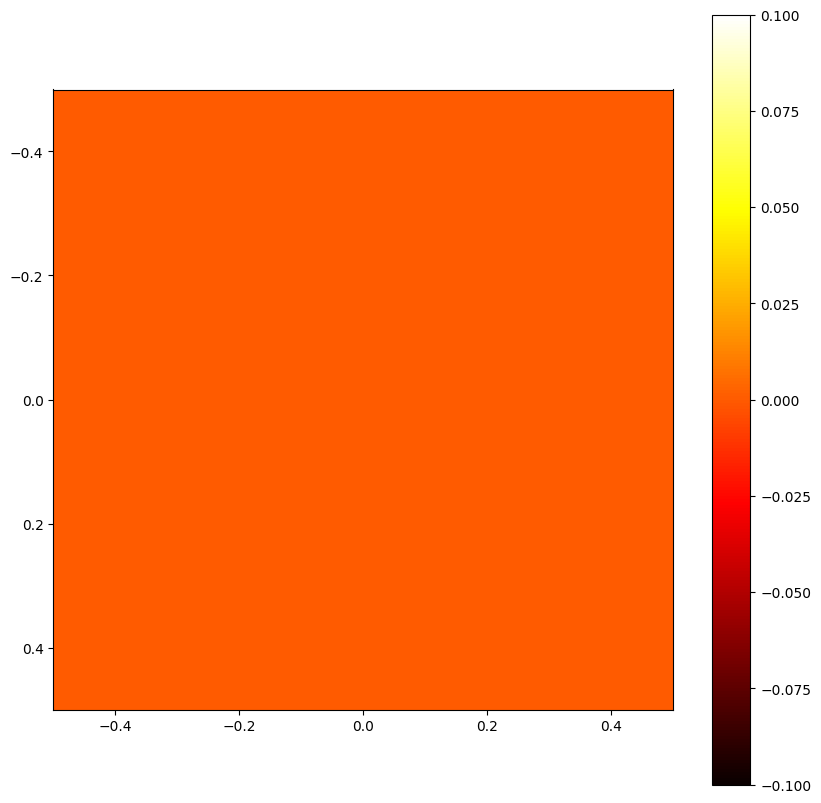

In [151]:
# квадратное сравнение векторов окон связности по Евклидовому расстоянию
from scipy.spatial import distance
L_plot_array = np.zeros((windows_count_to_analyse,windows_count_to_analyse))
for j in range(0,windows_count_to_analyse):
    for i in range(0,windows_count_to_analyse):
        L_plot_array[i,j] = distance.euclidean(temp_rows[j], temp_rows[i])

        
plt.figure(figsize=(10,10))
plt.imshow(L_plot_array, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.show()

In [152]:
# Блоки дальше для работы с кластеризацией состояний (если получится...)

In [153]:
# Создаем из матрицы - вектор без нулей, чтобы кластеризовать
vectors_for_clastering = np.empty((windows_count_to_analyse),dtype=object)
for i in range(0,windows_count_to_analyse):
    vectors_for_clastering[i] = matrix2line(array2csv[i])
    
# создаем из массива одномерных векторов матрицу (двумерный массив), чтобы можно было анализировать
vectors_for_clastering_array = np.zeros((windows_count_to_analyse,len(vectors_for_clastering[0])))

for i in range(0,windows_count_to_analyse):
    for j in range(0,len(vectors_for_clastering[0])):
        vectors_for_clastering_array[i][j] = vectors_for_clastering[i][j]

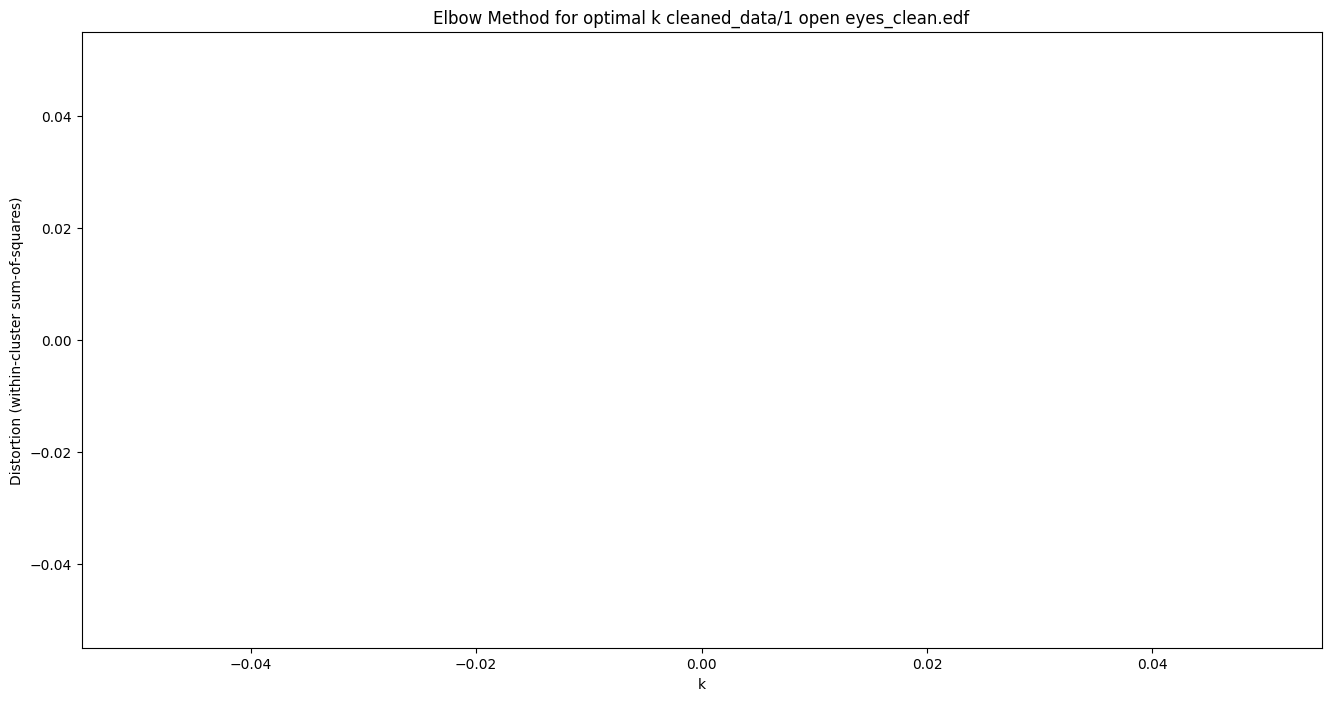

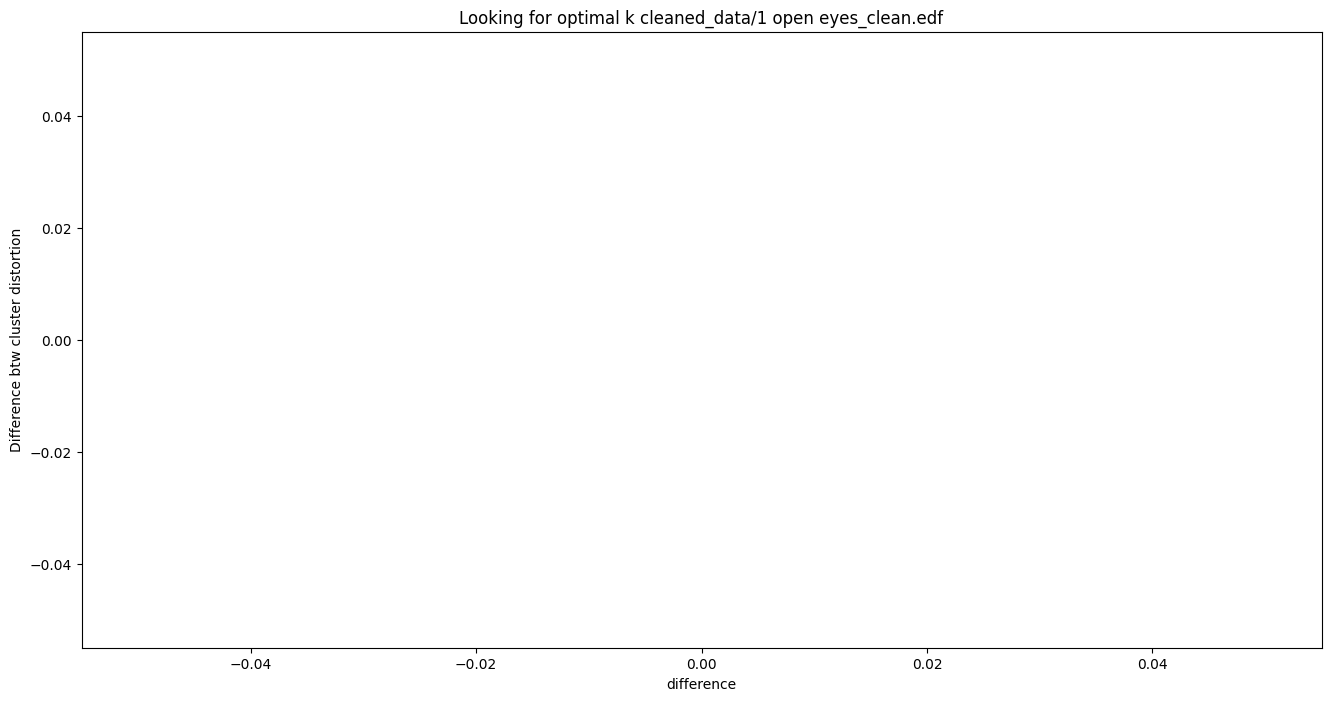

In [154]:
from sklearn.cluster import KMeans
# делаем анализ простейшей кластеризации векторов по количеству сегментов - есть ли хорошее количество?
distortions = []
K = range(2,windows_count_to_analyse-1)
for k in K:
    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(vectors_for_clastering_array)
    distortions.append(kmeanModel.inertia_)
    
plt.figure(figsize=(16,8))
plt.plot(K, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion (within-cluster sum-of-squares)')
plt.title('Elbow Method for optimal k '+edffile_state_main)
plt.show()

analysis = []
for i in range(0,len(distortions)-1):
    analysis.append(abs(distortions[i+1]-distortions[i]))
plt.figure(figsize=(16,8))
plt.plot(K[0:len(K)-1], analysis, 'bx-')
plt.xlabel('difference')
plt.ylabel('Difference btw cluster distortion')
plt.title('Looking for optimal k '+edffile_state_main)
plt.show()

In [155]:
# количество попыток кластеризации
N = 3
# количество кластеров
clusts = 2

# Кластеризация возможна только если окон не меньше 2.
kmeans_array = []
if windows_count_to_analyse < 2:
    print('Not enough windows for clustering: windows_count_to_analyse = ' + str(windows_count_to_analyse))
else:
    clusts = min(clusts, windows_count_to_analyse)
    for i in range(0, N):
        kmeans = KMeans(n_clusters=clusts, random_state=i, n_init='auto')
        kmeans.fit(vectors_for_clastering_array)
        kmeans_array.append(kmeans.labels_)

        time_index = np.arange(1, windows_count_to_analyse + 1)
        # строим график изменения состояний по времени
        plt.figure(figsize=(16,4))
        plt.scatter(time_index, kmeans_array[i])
        plt.xlabel('')
        plt.ylabel('State')
        plt.title('States over time for ' + edffile_state_main)
        plt.show()

Not enough windows for clustering: windows_count_to_analyse = 1


In [156]:
# строим матрицу из 0 и 1, которая показывает, где одинаковые кластера, чтобы убрать зависимость от номеров кластеров
if len(kmeans_array) == 0:
    print('Consensus matrix skipped: clustering was not run because there are not enough windows')
else:
    matrix_0_1 = np.zeros((windows_count_to_analyse,windows_count_to_analyse))
    for a in range(0, len(kmeans_array)):
        temp_matrix_0_1 = np.zeros((windows_count_to_analyse,windows_count_to_analyse))
        for i in range(0,windows_count_to_analyse):
            for j in range(0,windows_count_to_analyse):
                if kmeans_array[a][i] == kmeans_array[a][j]:
                    temp_matrix_0_1[i][j] = 1
        matrix_0_1 += temp_matrix_0_1

    plt.figure(figsize=(10,10))
    plt.matshow(matrix_0_1)

Consensus matrix skipped: clustering was not run because there are not enough windows


In [157]:
# Теперь анализ "крутыми" картинками

In [158]:
# Немного кастомизированная функция из стандартного пакета

from scipy import linalg
def plot_sensors_connectivity2(_filename, info, con, picks=None):

    picks = mne.io.pick._picks_to_idx(info, picks)
    if len(picks) != len(con):
        raise ValueError('The number of channels picked (%s) does not '
                         'correspond the size of the connectivity data '
                         '(%s)' % (len(picks), len(con)))

    sens_loc = np.array([info['chs'][k]['loc'][:3] for k in picks])
    xy = sens_loc[:, :2]

    n_con = min(36, con.size)
    min_dist = 0.05
    threshold = np.sort(con, axis=None)[-n_con]
    ii, jj = np.where(con >= threshold)

    con_nodes = []
    con_val = []
    for i, j in zip(ii, jj):
        if i == j:
            continue
        if linalg.norm(sens_loc[i] - sens_loc[j]) > min_dist:
            con_nodes.append((i, j))
            con_val.append(con[i, j])

    plt.figure(figsize=(8, 8))
    ax = plt.gca()
    ax.set_facecolor('#f5f5f5')

    if len(con_val) > 0:
        con_val = np.array(con_val)
        vmax = np.max(con_val)
        vmin = np.min(con_val)
        norm = plt.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.cm.Blues
        for val, nodes in zip(con_val, con_nodes):
            x1, y1 = xy[nodes[0]]
            x2, y2 = xy[nodes[1]]
            ax.plot([x1, x2], [y1, y2], color=cmap(norm(val)), linewidth=2, alpha=0.9)
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, shrink=0.8, label='Coherence')

    ax.scatter(xy[:, 0], xy[:, 1], s=140, c='white', edgecolors='black', zorder=3)
    for node, ch_idx in enumerate(picks):
        x, y = xy[node]
        ax.text(x, y, info['ch_names'][ch_idx], ha='center', va='center', fontsize=10, zorder=4)

    ax.set_title('Coherence for\n' + _filename)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.show()
    return ax

In [159]:
# Указываем общипринятые координаты данных электродов для рисования 6ти точек
epochs = mne.Epochs(raw_mne_main, events, tmin=0, tmax=epoch_length, picks=picks,baseline=None)
# F3
epochs.info['chs'][2]['loc'] = [-0.04815716, 0.05090548, 0.04043975,0,0,0,0,0,0,0,0,0]
# F4
epochs.info['chs'][3]['loc'] = [0.04968343, 0.0520495, 0.03911898,0,0,0,0,0,0,0,0,0]
# T3 (T7)
epochs.info['chs'][1]['loc'] = [-0.08066586, -0.01535344, -0.00895786,0,0,0,0,0,0,0,0,0]
# T4 (T8)
epochs.info['chs'][4]['loc'] = [0.08154651, -0.0143965, -0.00909588,0,0,0,0,0,0,0,0,0]
# O1
epochs.info['chs'][0]['loc'] = [-0.02819185, -0.10777896, 0.00847191,0,0,0,0,0,0,0,0,0]
# O2
epochs.info['chs'][5]['loc'] = [0.02860323, -0.10749813, 0.00843453,0,0,0,0,0,0,0,0,0]

Not setting metadata
6 matching events found
No baseline correction applied
0 projection items activated


In [160]:
# везде работаем со значением связностей в каком-то кусочке записи array2csv[i], где i - это номер окна для анализа
# или можно сделать большое окно - то всю запись помещаем в одно окно, надо поменять window_length например до 60 секунд

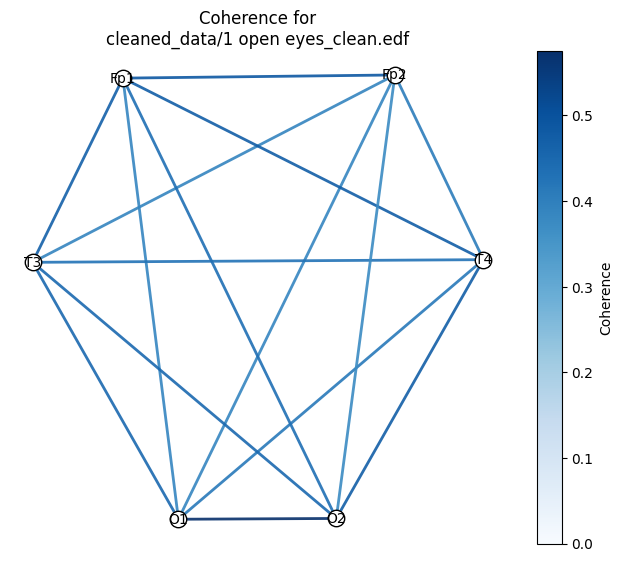

<Axes: title={'center': 'Coherence for\ncleaned_data/1 open eyes_clean.edf'}>

In [161]:
# рисуем картинку связности по первому окну
plot_sensors_connectivity2(edffile_state_main, epochs.info, array2csv[0], picks)

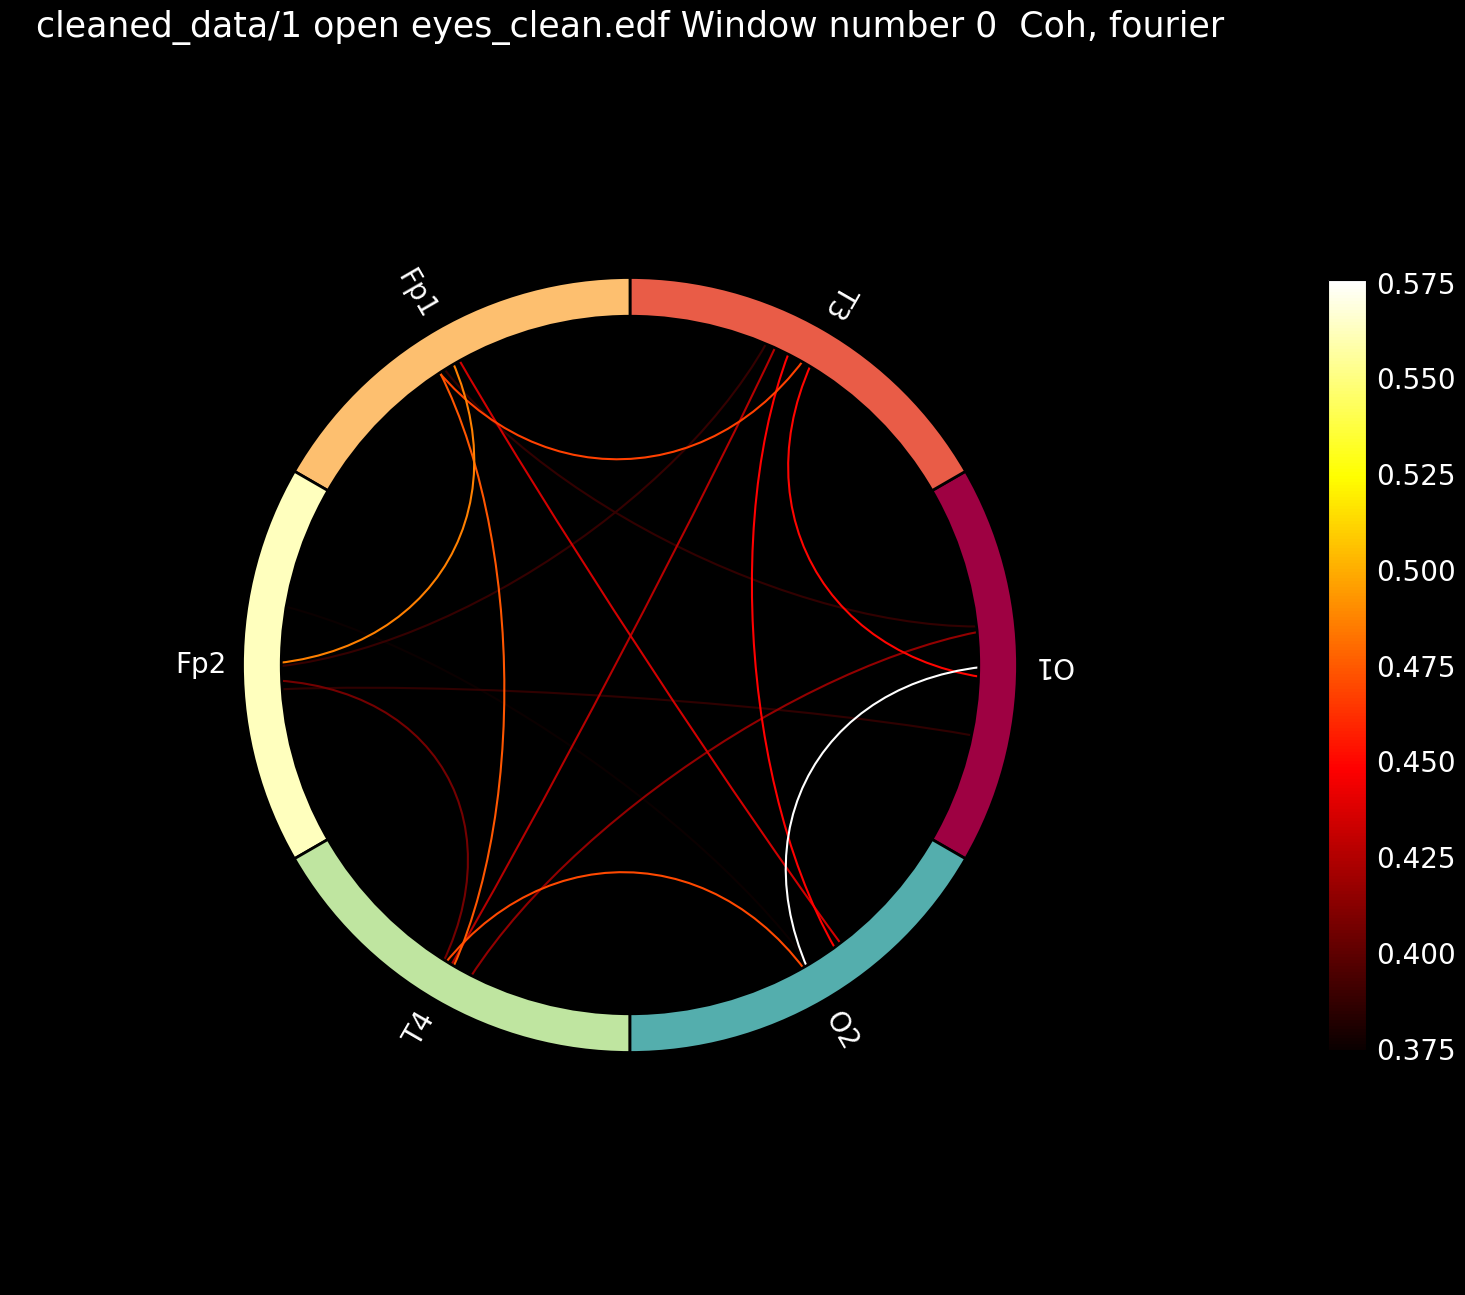

(<Figure size 2000x2000 with 2 Axes>,
 <PolarAxes: title={'center': 'cleaned_data/1 open eyes_clean.edf Window number 0  Coh, fourier'}>)

In [162]:
# рисуем круг связности по первому окну
fig = plt.figure(num=None, figsize=(20, 20), facecolor='black')
ax = fig.add_subplot(111, polar=True)
plot_connectivity_circle(array2csv[0], raw_mne_main.info['ch_names'][0:nchan],n_lines=36,
                         title=edffile_state_main +" Window number 0 " + " Coh, fourier", fontsize_names=20, node_linewidth=2.0, colorbar_size=0.5, 
                         fontsize_colorbar=20, colorbar_pos=(0, 0.5), fontsize_title=25, ax=ax)

In [163]:
# рисуем разностную картинку связности между 2мя кусочками 
# !!! вам надо потом так поправить код, чтобы можно было нарисовать между 2мя записями
if windows_count_to_analyse >= 4:
    plot_sensors_connectivity2(edffile_state_main, epochs.info, array2csv[3] - array2csv[1], picks)
else:
    print('Not enough windows to draw difference connectivity: need at least 4 windows')

Not enough windows to draw difference connectivity: need at least 4 windows


In [164]:
# рисуем разностный круг связности между 2мя кусочками 
# !!! вам надо потом так поправить код, чтобы можно было нарисовать между 2мя записями
if windows_count_to_analyse >= 4:
    fig = plt.figure(num=None, figsize=(20, 20), facecolor='black')
    ax = fig.add_subplot(111, polar=True)
    plot_connectivity_circle(array2csv[3] - array2csv[1], raw_mne_main.info['ch_names'][0:nchan],n_lines=36,
                             title=edffile_state_main +" Window number 3 - 1 " + " Coh, fourier", fontsize_names=20, node_linewidth=2.0, colorbar_size=0.5, 
                             fontsize_colorbar=20, colorbar_pos=(0, 0.5), fontsize_title=25, ax=ax)
else:
    print('Not enough windows to draw difference connectivity circle: need at least 4 windows')

Not enough windows to draw difference connectivity circle: need at least 4 windows
